# Lab Day 2 — Backbone, công thức huấn luyện và suy luận trên DeepWeeds

Notebook **khung** cho Colab hoặc Kaggle. Các ô có chữ `TODO` là phần **bạn tự viết**; ô cài đặt, tải dữ liệu
và chạy `eval.py` đã viết sẵn. Đọc `README.md` (quy tắc chia dữ liệu, cách đánh giá), `GUIDE.md` và `RUBRIC.md` trước.

**Quy tắc quan trọng nhất:** chọn mọi thứ trên **val**; **test chỉ chạy một lần mỗi seed ở Bước 4**.

Bản đồ: Bước 0 (EDA, kiểm tra) → Bước 1 (backbone) → Bước 2 (công thức huấn luyện) → Bước 3 (suy luận)
→ Bước 4 (chung kết + `eval.py`) → Bước 5 (xlsx, biểu đồ, báo cáo).

## 0. Cài đặt môi trường

In [7]:
import os
import zipfile
from pathlib import Path

input_root = Path("/kaggle/input")

def find_repo(root):
    return [
        p.parent
        for p in root.rglob("eval.py")
        if (
            p.parent
            / "submissions/2A202602941_LeTrongKhanh/code/train.py"
        ).is_file()
    ]

repos = find_repo(input_root)

# Hỗ trợ trường hợp ZIP vẫn còn nguyên trong Input.
if not repos:
    archives = list(input_root.rglob("lab_day2_code.zip"))
    assert len(archives) == 1, (
        "Hãy Add Input dataset chứa lab_day2_code.zip"
    )
    extracted = Path("/kaggle/working/lab_day2_code")
    extracted.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(archives[0]) as archive:
        archive.extractall(extracted)

    repos = find_repo(extracted)

assert len(repos) == 1, (
    f"Cần đúng một thư mục dự án, tìm được: {repos}"
)

os.environ["LAB_REPO_DIR"] = str(repos[0])
os.environ["LAB_OUTPUT_DIR"] = (
    "/kaggle/working/lab_day2_output"
)

# Dataset tải vào ổ tạm; kết quả ghi riêng vào working.
runtime_dir = Path("/tmp/lab_day2_runtime")
runtime_dir.mkdir(parents=True, exist_ok=True)
os.chdir(runtime_dir)

print("Code:", os.environ["LAB_REPO_DIR"])
print("Kết quả:", os.environ["LAB_OUTPUT_DIR"])

Code: /kaggle/input/datasets/ltrngkhnh/lab-day2-code/K4-DAY02-LeTrongKhanh-2A202602941
Kết quả: /kaggle/working/lab_day2_output


In [8]:
# Cài thư viện (Colab/Kaggle). Kaggle: bật Internet trong Settings.
!pip -q install timm openpyxl

import sys, os, platform
import numpy as np, pandas as pd, torch, timm

# Đã `git clone` repo bài lab vào thư mục này (đổi nếu bạn đặt chỗ khác).
REPO_DIR = "K4-Track4-Day2-Deeplearning-Advance"
sys.path.insert(0, REPO_DIR)                 # để import eval.py
sys.path.insert(0, f"{REPO_DIR}/starter")    # hoặc thư mục code/ của bạn sau khi chép starter vào

print("python", platform.python_version(), "| torch", torch.__version__, "| timm", timm.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")

python 3.13.15 | torch 2.11.0+cu128 | timm 1.0.29
GPU: Tesla T4


### Tải dữ liệu (đã viết sẵn)
Ảnh từ Zenodo (~490 MB, kiểm tra MD5), nhãn và các file chia fold từ GitHub của tác giả.
**Sau khi giải nén, hãy `ls` để xem ảnh nằm ở thư mục nào** rồi đặt `IMAGES_DIR` cho đúng.

In [9]:
import hashlib

os.makedirs("data/labels", exist_ok=True)
if not os.path.exists("data/images.zip"):
    !wget -q -O data/images.zip "https://zenodo.org/records/7939060/files/images.zip?download=1"

h = hashlib.md5()
with open("data/images.zip", "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai: {h.hexdigest()}"

!unzip -q -n data/images.zip -d data/
!ls data | head

BASE = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for name in ["labels", "train_subset0", "val_subset0", "test_subset0"]:
    !wget -q -O data/labels/{name}.csv {BASE}/{name}.csv
!ls -la data/labels

20160928-140314-0.jpg
20160928-140337-0.jpg
20160928-140731-0.jpg
20160928-140747-0.jpg
20160928-141107-0.jpg
20160928-141135-0.jpg
20160928-141355-0.jpg
20160928-141421-0.jpg
20160928-141437-0.jpg
20160928-142056-0.jpg
ls: write error: Broken pipe
total 1808
drwxr-xr-x 2 root root   4096 Oct  5 12:11 .
drwxr-xr-x 3 root root 815104 Oct  5 12:11 ..
-rw-r--r-- 1 root root 598898 Oct  5 12:13 labels.csv
-rw-r--r-- 1 root root  84183 Oct  5 12:13 test_subset0.csv
-rw-r--r-- 1 root root 252039 Oct  5 12:13 train_subset0.csv
-rw-r--r-- 1 root root  84039 Oct  5 12:13 val_subset0.csv


In [10]:
from pathlib import Path
image_files = sorted(Path("data").rglob("*.jpg"))
if not image_files:
    raise FileNotFoundError("Không tìm thấy ảnh .jpg sau giải nén")
parents = {p.parent for p in image_files}
if len(parents) != 1:
    raise ValueError(f"Ảnh nằm trong nhiều thư mục: {parents}")
IMAGES_DIR = str(next(iter(parents)).resolve())
LABELS_DIR = str(Path("data/labels").resolve())
print("IMAGES_DIR:", IMAGES_DIR)


IMAGES_DIR: /tmp/lab_day2_runtime/data


## Bước 0 — EDA và kiểm tra pipeline
Mục tiêu: hiểu dữ liệu, chạy các kiểm tra chia dữ liệu (README mục 2.1), kiểm tra pipeline trước khi chạy thật.

{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': 0, 'train_test': 0, 'val_test': 0}, 'union': 17509}


,train,val,test
Chinee Apple,675,225,226
Lantana,637,213,213
Parkinsonia,618,206,207
Parthenium,613,204,205
Prickly Acacia,637,212,213
Rubber Vine,605,202,202
Siam Weed,644,215,215
Snake Weed,609,203,204
Negatives,5463,1821,1822


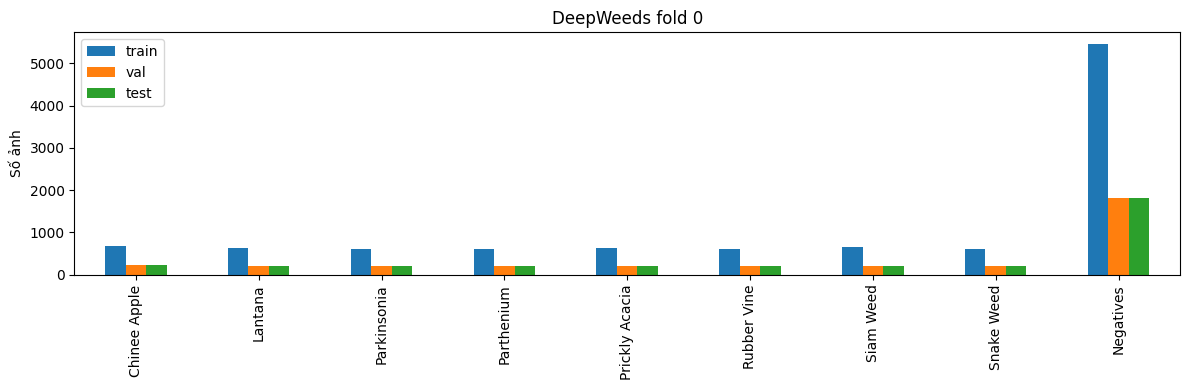

,thực tế,Table 1,chênh lệch
Chinee Apple,1126,1125,1
Lantana,1063,1064,-1
Parkinsonia,1031,1031,0
Parthenium,1022,1022,0
Prickly Acacia,1062,1062,0
Rubber Vine,1009,1009,0
Siam Weed,1074,1074,0
Snake Weed,1016,1016,0
Negatives,9106,9106,0


Tỷ lệ lớp lớn nhất/nhỏ nhất: 9.024777006937562
20170627-103832-0.jpg (256, 256) RGB
20170811-104420-2.jpg (256, 256) RGB
20170217-103631-0.jpg (256, 256) RGB
20170714-141718-3.jpg (256, 256) RGB
20170714-132633-1.jpg (256, 256) RGB
20170714-142008-2.jpg (256, 256) RGB
20170920-181043-1.jpg (256, 256) RGB
20170920-182841-1.jpg (256, 256) RGB
20171102-122608-3.jpg (256, 256) RGB
20171025-074113-2.jpg (256, 256) RGB
20170913-102301-2.jpg (256, 256) RGB
20171025-082751-2.jpg (256, 256) RGB
20171102-093311-2.jpg (256, 256) RGB
20170729-085956-2.jpg (256, 256) RGB
20170727-170810-3.jpg (256, 256) RGB
20170913-100725-3.jpg (256, 256) RGB
20171109-092912-1.jpg (256, 256) RGB
20170913-101319-3.jpg (256, 256) RGB
20171113-150347-1.jpg (256, 256) RGB
20171113-120426-1.jpg (256, 256) RGB
20171113-133312-1.jpg (256, 256) RGB
20170210-141909-0.jpg (256, 256) RGB
20170704-150456-0.jpg (256, 256) RGB
20170705-161808-0.jpg (256, 256) RGB
20180119-110729-2.jpg (256, 256) RGB
20180105-100326-3.jpg (256, 

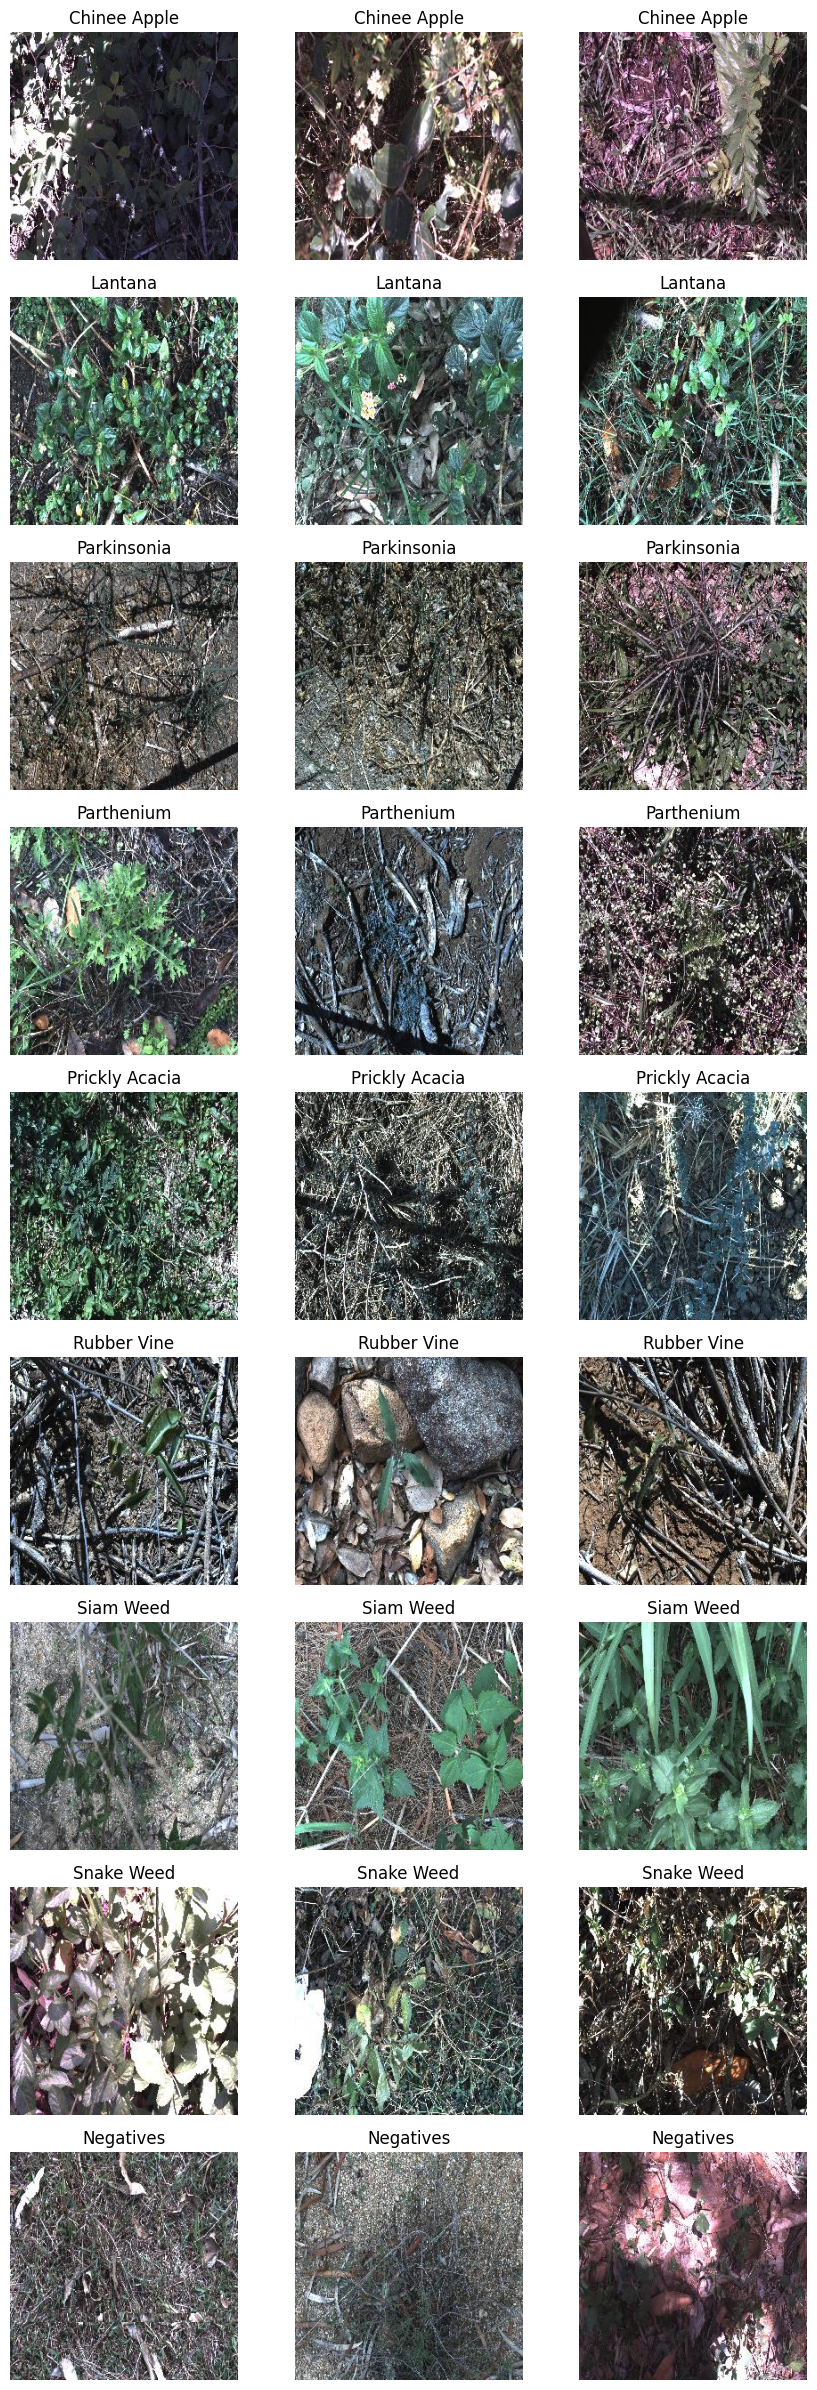

In [11]:
import json, gc, time, copy
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from dataclasses import replace, asdict

REPO_DIR = str(Path(os.environ.get("LAB_REPO_DIR", REPO_DIR)).resolve())
CODE_DIR = Path(REPO_DIR) / "submissions/2A202602941_LeTrongKhanh/code"
assert (CODE_DIR / "train.py").is_file(), f"Không tìm thấy code tại {CODE_DIR}"
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, str(CODE_DIR))
import dataset, model as models, losses, inference, benchmark
from train import Config, run, run_dir, set_seed
from eval import compute_metrics, save_predictions, read_pred, check_against_csv, SCALARS

OUTPUT_DIR = Path(os.environ.get("LAB_OUTPUT_DIR", "/content/lab_day2_output")).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(OUTPUT_DIR)
BASE = Config(images_dir=IMAGES_DIR, labels_dir=LABELS_DIR,
              out_dir=str(OUTPUT_DIR / "runs"), pred_dir=str(OUTPUT_DIR / "predictions"))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert DEVICE.type == "cuda", "Bật GPU trong Runtime > Change runtime type trước thí nghiệm"
train_df, val_df, test_df = dataset.load_split(LABELS_DIR)
split_stats = dataset.check_split(train_df, val_df, test_df, IMAGES_DIR)
(OUTPUT_DIR / "split_stats.json").write_text(json.dumps(split_stats, indent=2))
counts = pd.DataFrame(split_stats["per_class"]).reindex(range(9))
counts.index = dataset.CLASS_NAMES
display(counts)
ax = counts.plot.bar(figsize=(12, 4))
ax.set_ylabel("Số ảnh"); ax.set_title("DeepWeeds fold 0")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_counts.png", dpi=160); plt.show()
expected = np.array([1125, 1064, 1031, 1022, 1062, 1009, 1074, 1016, 9106])
display(pd.DataFrame({"thực tế": counts.sum(axis=1), "Table 1": expected,
                      "chênh lệch": counts.sum(axis=1).to_numpy() - expected}))
print("Tỷ lệ lớp lớn nhất/nhỏ nhất:", counts.sum(axis=1).max() / counts.sum(axis=1).min())
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
fig, axes = plt.subplots(9, 3, figsize=(9, 24))
for c in range(9):
    sample = all_df[all_df.Label == c].sample(3, random_state=0)
    for ax, row in zip(axes[c], sample.itertuples()):
        with Image.open(Path(IMAGES_DIR) / row.Filename) as im:
            print(row.Filename, im.size, im.mode)
            ax.imshow(im.convert("RGB"))
        ax.set_title(dataset.CLASS_NAMES[c]); ax.axis("off")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "eda_samples.png", dpi=120); plt.show()

def load_net(summary):
    cfg = Config(**summary["config"])
    net = models.build_model(cfg.backbone, pretrained=False, init=cfg.init, drop_rate=cfg.drop_rate).to(DEVICE)
    net.load_state_dict(torch.load(summary["checkpoint"], map_location=DEVICE, weights_only=True)["model"])
    return net.eval()

def loader_for(net, df, size, batch=64):
    pcfg = net.pretrained_cfg
    tf = dataset.build_transforms(False, size, mean=pcfg.get("mean", dataset.IMAGENET_MEAN),
                                 std=pcfg.get("std", dataset.IMAGENET_STD))
    return dataset.make_loader(df, IMAGES_DIR, tf, batch, False, num_workers=BASE.num_workers)

def save_table(rows, name):
    pd.DataFrame(rows).to_json(OUTPUT_DIR / name, orient="records", indent=2)


CE ban đầu: 2.1960642337799072 | ln(9): 2.1972245773362196
Loss cuối overfit: 0.017691008746623993 | bước: 67


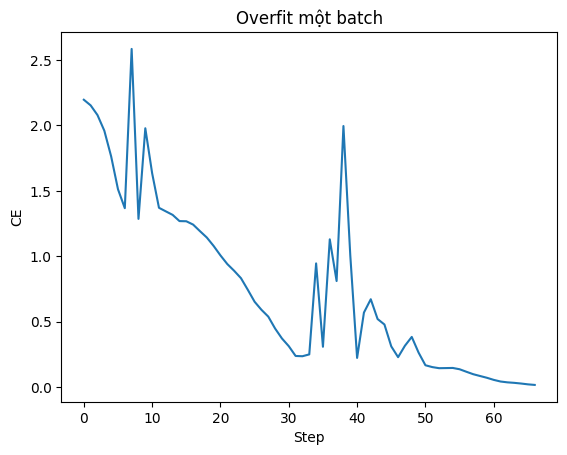

Focal gamma=0 so với CE: 0.0
CutMix lam thực: 0.4833984375


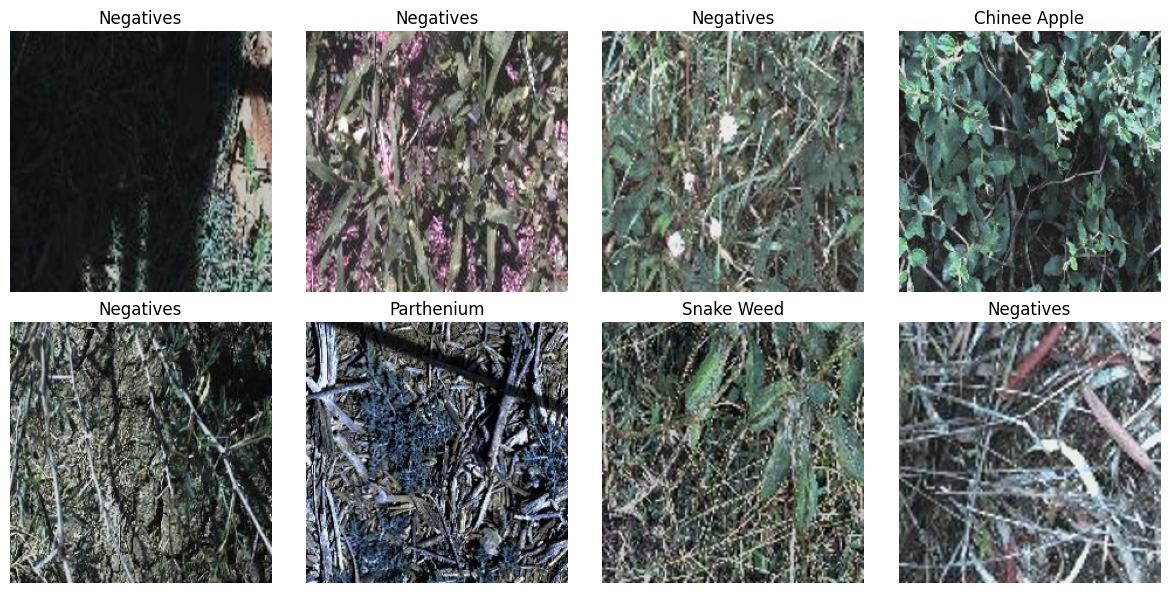

In [12]:
set_seed(0)
tf = dataset.build_transforms(False, 224)
small = train_df.groupby("Label", group_keys=False).head(2)
small_loader = dataset.make_loader(small, IMAGES_DIR, tf, len(small), False, num_workers=0)
x, y, names = next(iter(small_loader))
x, y = x.to(DEVICE), y.to(DEVICE)
probe = models.build_model("resnet50", pretrained=False, init="scratch").to(DEVICE)
probe.eval()
with torch.no_grad():
    initial_loss = torch.nn.functional.cross_entropy(probe(x), y).item()
print("CE ban đầu:", initial_loss, "| ln(9):", np.log(9))
optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3)
overfit_history = []
# eval giữ BN/dropout cố định; gradient vẫn bật để overfit đúng batch cố định.
for step in range(500):
    optimizer.zero_grad(set_to_none=True)
    loss = torch.nn.functional.cross_entropy(probe(x), y)
    loss.backward(); optimizer.step()
    overfit_history.append(float(loss.detach()))
    if overfit_history[-1] < .02:
        break
print("Loss cuối overfit:", overfit_history[-1], "| bước:", len(overfit_history))
assert overfit_history[-1] < .05, "Chưa overfit được: kiểm tra pipeline trước khi tiếp tục"
plt.plot(overfit_history); plt.xlabel("Step"); plt.ylabel("CE"); plt.title("Overfit một batch")
plt.savefig(OUTPUT_DIR / "pipeline_overfit.png", dpi=160); plt.show()
z = torch.randn(16, 9, device=DEVICE); target = torch.arange(16, device=DEVICE) % 9
difference = abs((losses.FocalLoss(gamma=0)(z, target) -
                  torch.nn.functional.cross_entropy(z, target)).item())
print("Focal gamma=0 so với CE:", difference)
assert difference < 1e-6
sentinel = torch.zeros(2, 3, 32, 32, device=DEVICE); sentinel[1] = 1
mixed, (_, yb, lam) = losses.mix_batch(sentinel, torch.tensor([0, 1], device=DEVICE), mode="cutmix")
if yb[0].item() == 1:
    assert abs(mixed[0, 0].mean().item() - (1 - lam)) < 1e-6
print("CutMix lam thực:", lam)
aug_loader = dataset.make_loader(train_df, IMAGES_DIR, dataset.build_transforms(True, 224, "color"),
                                 8, True, num_workers=0)
aug_x, aug_y, _ = next(iter(aug_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image, label in zip(axes.flat, aug_x, aug_y):
    image = image * torch.tensor(dataset.IMAGENET_STD)[:, None, None] + torch.tensor(dataset.IMAGENET_MEAN)[:, None, None]
    ax.imshow(image.permute(1, 2, 0).clamp(0, 1))
    ax.set_title(dataset.CLASS_NAMES[int(label)]); ax.axis("off")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "pipeline_aug.png", dpi=160); plt.show()
del probe, optimizer, x, y
gc.collect(); torch.cuda.empty_cache()


## Bước 1 — So sánh backbone (≥ 5)
Cùng công thức nền `T00` (GUIDE.md mục 1.4), cùng seed, mỗi backbone một lần chạy. Mã thí nghiệm `B01`, `B02`, ...

In [13]:
backbone_rows, latency_rows = [], []
backbone_names = ["resnet50", "resnext50_32x4d", "convnext_tiny",
                  "deit_small_patch16_224", "efficientnet_b0"]
for i, name in enumerate(backbone_names, 1):
    summary = run(replace(BASE, exp_id=f"B{i:02d}", backbone=name, seed=0))
    net = load_net(summary)
    timing = benchmark.latency_report(net, 1, BASE.img_size, device=str(DEVICE))
    summary.update({"latency_batch1_ms": timing["p50"], "notes": "cùng T00; mới 1 seed"})
    backbone_rows.append(summary)
    latency_rows.append({"exp_id": summary["exp_id"], **timing})
    save_table(backbone_rows, "backbones.json"); save_table(latency_rows, "latency.json")
    del net; gc.collect(); torch.cuda.empty_cache()
ranked = sorted(backbone_rows, key=lambda r: (-r["macro_f1_val"], r["latency_batch1_ms"]))
SELECTED_BACKBONE = ranked[0]["backbone"]
PARTNER_SUMMARY = ranked[1]
display(pd.DataFrame(backbone_rows).drop(columns=["config"]))
print("Đi tiếp:", SELECTED_BACKBONE, "và", PARTNER_SUMMARY["backbone"])
print("Quy tắc: macro-F1 val giảm dần, hòa chọn latency thấp; xem đánh đổi trong bảng trước khi kết luận.")


{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': 0, 'train_test': 0, 'val_test': 0}, 'union': 17509}


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

B01 0 {'epoch': 1, 'train_loss': 1.653467512712246, 'lr': 0.001, 'val_loss': 1.2280747357929342, 'val_macro_f1': 0.2067959415154212, 'val_top1': 0.5586975149957155, 'train_seconds': 40.686666608999985}
B01 0 {'epoch': 2, 'train_loss': 0.9748539713824668, 'lr': 0.0009802342017756378, 'val_loss': 0.753472191747411, 'val_macro_f1': 0.6400201928164042, 'val_top1': 0.7423593259068837, 'train_seconds': 42.120029359}
B01 0 {'epoch': 3, 'train_loss': 0.6900174588691897, 'lr': 0.0009215657172637579, 'val_loss': 0.585239753948556, 'val_macro_f1': 0.737237108108569, 'val_top1': 0.8026278206226792, 'train_seconds': 41.01117022200003}
B01 0 {'epoch': 4, 'train_loss': 0.5713461348559798, 'lr': 0.0008287444854870252, 'val_loss': 0.4842986196015638, 'val_macro_f1': 0.7769145004331837, 'val_top1': 0.8351899457297914, 'train_seconds': 41.34133317199996}
B01 0 {'epoch': 5, 'train_loss': 0.49822929728685356, 'lr': 0.0007092903306148697, 'val_loss': 0.44743574399397873, 'val_macro_f1': 0.7927460279802327, 

/usr/local/lib/python3.13/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


...

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

B05 0 {'epoch': 1, 'train_loss': 2.166863383316412, 'lr': 0.001, 'val_loss': 1.2341269272390485, 'val_macro_f1': 0.49384115173567394, 'val_top1': 0.614110254213082, 'train_seconds': 37.67249906200004}
B05 0 {'epoch': 2, 'train_loss': 0.8176992346600789, 'lr': 0.0009799910721210753, 'val_loss': 0.8296387780567334, 'val_macro_f1': 0.6326330788045399, 'val_top1': 0.729791488146244, 'train_seconds': 27.811094253999727}
B05 0 {'epoch': 3, 'train_loss': 0.5654249280327703, 'lr': 0.0009210968803656914, 'val_loss': 0.5774966397478866, 'val_macro_f1': 0.7479164434991632, 'val_top1': 0.8089117395029991, 'train_seconds': 27.77960377999989}
B05 0 {'epoch': 4, 'train_loss': 0.4358267425218733, 'lr': 0.0008287444854870252, 'val_loss': 0.5045970645811653, 'val_macro_f1': 0.7691907635816466, 'val_top1': 0.8303341902313625, 'train_seconds': 27.828304133000074}
B05 0 {'epoch': 5, 'train_loss': 0.3614038825035095, 'lr': 0.0007092903306148697, 'val_loss': 0.42385100120648217, 'val_macro_f1': 0.81194652525

,exp_id,seed,backbone,best_epoch,macro_f1_val,top1_val,ece_val,f1_chinee_val,f1_snake_val,train_seconds_per_epoch,params_m,gmacs,img_size,epochs,weight_tag,checkpoint,latency_batch1_ms,notes
0,B01,0,resnet50,10,0.838223,0.880320,0.021192,0.700000,0.760705,41.306013,23.526473,4.087155,224,12,resnet50.a1_in1k,/kaggle/working/lab_day2_output/runs/B01/seed0...,6.912806,cùng T00; mới 1 seed
1,B02,0,resnext50_32x4d,12,0.870980,0.899457,0.004485,0.783251,0.806763,53.947784,22.998345,4.228450,224,12,resnext50_32x4d.a1h_in1k,/kaggle/working/lab_day2_output/runs/B02/seed0...,9.716416,cùng T00; mới 1 seed
2,B03,0,convnext_tiny,11,0.971149,0.977721,0.010022,0.949451,0.933661,48.838942,27.827049,4.456915,224,12,convnext_tiny.in12k_ft_in1k,/kaggle/working/lab_day2_output/runs/B03/seed0...,6.660179,cùng T00; mới 1 seed
3,B04,0,deit_small_patch16_224,12,0.955110,0.968295,0.006533,0.905830,0.899263,31.989822,21.669129,4.599901,224,12,deit_small_patch16_224.fb_in1k,/kaggle/working/lab_day2_output/runs/B04/seed0...,5.810005,cùng T00; mới 1 seed
4,B05,0,efficientnet_b0,10,0.852542,0.888603,0.021200,0.757282,0.804819,28.759021,4.019077,0.385805,224,12,efficientnet_b0.ra_in1k,/kaggle/working/lab_day2_output/runs/B05/seed0...,9.417827,cùng T00; mới 1 seed


Đi tiếp: convnext_tiny và deit_small_patch16_224
Quy tắc: macro-F1 val giảm dần, hòa chọn latency thấp; xem đánh đổi trong bảng trước khi kết luận.


## Bước 2 — Công thức huấn luyện (≥ 3 trục)
Mỗi lần chạy chỉ khác `T00` **một yếu tố**. Mã `T01`, `T02`, ... Ghi rõ khác ở điểm nào.

In [14]:
BASE = replace(BASE, backbone=SELECTED_BACKBONE)
baseline_summary = run(BASE)
training_rows = [{"axis": "baseline", "change": "T00", "delta": 0, **baseline_summary}]
variants = [
    ("T01", "A", {"init": "scratch"}), ("T02", "A", {"init": "frozen"}),
    ("T03", "B", {"aug": "color"}), ("T04", "B", {"aug": "randaug"}),
    ("T05", "B", {"mix": "mixup"}), ("T06", "B", {"mix": "cutmix"}),
    ("T07", "C", {"loss": "ls", "label_smoothing": .1}),
    ("T08", "C", {"loss": "focal"}),
    ("T09", "C", {"loss": "ce_weighted"}),
    ("T10", "D", {"sampler": "balanced"}),
    ("T11", "E", {"lr_head": BASE.lr_backbone}),
    ("T12", "F", {"ema_decay": .999}),
]
for exp_id, axis, changes in variants:
    summary = run(replace(BASE, exp_id=exp_id, **changes))
    training_rows.append({**summary, "axis": axis, "change": json.dumps(changes),
                          "delta": summary["macro_f1_val"] - baseline_summary["macro_f1_val"]})
    save_table(training_rows, "training.json")
if "patch" not in BASE.backbone:
    summary = run(replace(BASE, exp_id="T13", img_size=256))
    training_rows.append({**summary, "axis": "G", "change": "img_size=256",
                          "delta": summary["macro_f1_val"] - baseline_summary["macro_f1_val"]})
summary = run(replace(BASE, exp_id="T14", epochs=20))
training_rows.append({**summary, "axis": "G", "change": "epochs=20",
                      "delta": summary["macro_f1_val"] - baseline_summary["macro_f1_val"]})
combo_changes = {}
for axis in ("B", "C", "F"):
    best = max([r for r in training_rows if r["axis"] in (axis, "baseline")],
               key=lambda r: r["macro_f1_val"])
    if best["axis"] != "baseline":
        combo_changes.update(json.loads(best["change"]))
if len(combo_changes) < 2:
    combo_changes = {"mix": "cutmix", "loss": "ls", "label_smoothing": .1, "ema_decay": .999}
combo_summary = run(replace(BASE, exp_id="T15", **combo_changes))
training_rows.append({**combo_summary, "axis": "combination", "change": json.dumps(combo_changes),
                      "delta": combo_summary["macro_f1_val"] - baseline_summary["macro_f1_val"]})
BEST_TRAIN = max(training_rows, key=lambda r: r["macro_f1_val"])
FINAL_CFG = replace(Config(**BEST_TRAIN["config"]), exp_id="F01")
noise_rows = []
for seed in (0, 1, 2):
    for cfg in (replace(BASE, seed=seed), replace(FINAL_CFG, seed=seed)):
        noise_rows.append(run(cfg))
save_table(noise_rows, "noise.json")
for tag in ("T00", "F01"):
    values = [r["macro_f1_val"] for r in noise_rows if r["exp_id"] == tag]
    print(tag, "macro-F1 val mean ± std:", np.mean(values), np.std(values, ddof=1))
print("Chênh lệch dưới std: không phân biệt được; các ablation khác mới 1 seed.")
save_table(training_rows, "training.json")
display(pd.DataFrame(training_rows).drop(columns=["config"]))


{'n': {'train': 10501, 'val': 3501, 'test': 3507}, 'per_class': {'train': {0: 675, 1: 637, 2: 618, 3: 613, 4: 637, 5: 605, 6: 644, 7: 609, 8: 5463}, 'val': {0: 225, 1: 213, 2: 206, 3: 204, 4: 212, 5: 202, 6: 215, 7: 203, 8: 1821}, 'test': {0: 226, 1: 213, 2: 207, 3: 205, 4: 213, 5: 202, 6: 215, 7: 204, 8: 1822}}, 'overlap': {'train_val': 0, 'train_test': 0, 'val_test': 0}, 'union': 17509}
T00 0 {'epoch': 1, 'train_loss': 0.8237143745873032, 'lr': 0.0009695121951219512, 'val_loss': 0.3284662760128058, 'val_macro_f1': 0.8649041222102516, 'val_top1': 0.895458440445587, 'train_seconds': 48.540729300000294}
T00 0 {'epoch': 2, 'train_loss': 0.31242185953731944, 'lr': 0.00098119214912082, 'val_loss': 0.251425808994166, 'val_macro_f1': 0.895791558424054, 'val_top1': 0.9177377892030848, 'train_seconds': 48.13245786199968}
T00 0 {'epoch': 3, 'train_loss': 0.22884516525877321, 'lr': 0.0009234282659572195, 'val_loss': 0.17006630692668248, 'val_macro_f1': 0.9262326168917543, 'val_top1': 0.944872893

,axis,change,delta,exp_id,seed,backbone,best_epoch,macro_f1_val,top1_val,ece_val,f1_chinee_val,f1_snake_val,train_seconds_per_epoch,params_m,gmacs,img_size,epochs,weight_tag,checkpoint
0,baseline,T00,0.000000,T00,0,convnext_tiny,11,0.971149,0.977721,0.010022,0.949451,0.933661,47.718365,27.827049,4.456915,224,12,convnext_tiny.in12k_ft_in1k,/kaggle/working/lab_day2_output/runs/T00/seed0...
1,A,"{""init"": ""scratch""}",-0.652606,T01,0,convnext_tiny,12,0.318543,0.579549,0.025495,0.256410,0.228571,48.274159,27.827049,4.456915,224,12,convnext_tiny.in12k_ft_in1k,/kaggle/working/lab_day2_output/runs/T01/seed0...
2,A,"{""init"": ""frozen""}",-0.120084,T02,0,convnext_tiny,11,0.851065,0.882319,0.038407,0.815851,0.789610,23.456023,27.827049,4.456915,224,12,convnext_tiny.in12k_ft_in1k,/kaggle/working/lab_day2_output/runs/T02/seed0...
3,B,"{""aug"": ""color""}",-0.000385,T03,0,convnext_tiny,10,0.970764,0.977721,0.011219,0.948775,0.930693,53.313533,27.827049,4.456915,224,12,convnext_tiny.in12k_ft_in1k,/kaggle/working/lab_day2_output/runs/T03/seed0...
4,B,"{""aug"": ""randaug""}",0.001868,T04,0,convnext_tiny,10,0.973017,0.978863,0.011126,0.948081,0.940594,47.962747,27.827049,4.456915,224,12,convnext_tiny.in12k_ft_in1k,/kaggle/working/lab_day2_output/runs/T04/seed0...
5,B,"{""mix"": ""mixup""}",-0.001061,T05,0,convnext_tiny,10,0.970088,0.977435,0.015977,0.952596,0.935323,48.746915,27.827049,4.456915,224,12,convnext_tiny.in12k_ft_in1k,/kaggle/working/lab_day2_output/runs/T05/seed0...
6,B,"{""mix"": ""cutmix""}",0.000685,T06,0,convnext_tiny,12,0.971834,0.978578,0.007232,0.950226,0.934940,48.560684,27.827049,4.456915,224,12,convnext_tiny.in12k_ft_in1k,/kaggle/working/lab_day2_output/runs/T06/seed0...
7,C,"{""loss"": ""ls"", ""label_smoothing"": 0.1}",0.003527,T07,0,convnext_tiny,12,0.974676,0.980577,0.087009,0.961276,0.936585,48.301882,27.827049,4.456915,224,12,convnext_tiny.in12k_ft_in1k,/kaggle/working/lab_day2_output/runs/T07/seed0...
8,C,"{""loss"": ""focal""}",0.001915,T08,0,convnext_tiny,10,0.973064,0.979434,0.030236,0.956332,0.942928,47.605821,27.827049,4.456915,224,12,convnext_tiny.in12k_ft_in1k,/kaggle/working/lab_day2_output/runs/T08/seed0...
9,C,"{""loss"": ""ce_weighted""}",0.000761,T09,0,convnext_tiny,12,0.971910,0.978863,0.010694,0.961969,0.930120,48.030891,27.827049,4.456915,224,12,convnext_tiny.in12k_ft_in1k,/kaggle/working/lab_day2_output/runs/T09/seed0...


## Bước 3 — Suy luận (≥ 4 phương pháp) và độ trễ
Làm trên **val**. Không huấn luyện lại. Mã `I00` (1 view, mốc), `I01`, ...

Sai số gộp BN: 0.0
Chọn từ val: {'exp_id': 'I02scale', 'mode': 'scale', 'K': 3, 'sizes': [224, 256, 288]}


,exp_id,mode,K,T,checkpoint,macro_f1_val,top1_val,ece_val,p50,p95,p99,images_per_s,relative_cost,space,resolution,sizes
0,I00,identity,1,1.000000,/kaggle/working/lab_day2_output/runs/F01/seed0...,0.976119,0.982576,0.007198,6.962825,7.682125,8.897985,143.619857,1.000000,NaN,NaN,NaN
1,I01,hflip,2,1.000000,/kaggle/working/lab_day2_output/runs/F01/seed0...,0.976100,0.982576,0.005647,14.303546,15.804150,16.402419,69.912736,2.054273,prob,NaN,NaN
2,I02,crop,5,1.000000,/kaggle/working/lab_day2_output/runs/F01/seed0...,0.975535,0.982291,0.005493,33.364520,36.439881,47.920797,29.971958,4.791808,prob,NaN,NaN
3,I03,hflip,2,1.000000,/kaggle/working/lab_day2_output/runs/F01/seed0...,0.976100,0.982576,0.005384,13.450362,14.455266,15.583354,74.347439,1.931739,logit,NaN,NaN
4,I07,temperature,1,1.203369,/kaggle/working/lab_day2_output/runs/F01/seed0...,0.976119,0.982576,0.003563,7.216292,7.923118,8.798686,138.575324,1.036403,NaN,NaN,NaN
5,I08amp,amp,1,1.000000,/kaggle/working/lab_day2_output/runs/F01/seed0...,0.976119,0.982576,0.007015,9.440595,14.199946,16.363655,105.925533,1.355857,NaN,NaN,NaN
6,I04,identity,1,1.000000,/kaggle/working/lab_day2_output/runs/F01/seed0...,0.973642,0.981148,0.008132,7.871224,12.776157,12.817219,127.045044,1.130464,NaN,288.0,NaN
7,I02scale,scale,3,1.000000,/kaggle/working/lab_day2_output/runs/F01/seed0...,0.978319,0.984290,0.003553,20.494884,22.093432,23.377635,48.792666,2.943472,NaN,NaN,"[224, 256, 288]"
8,I05,ensemble,2,1.000000,/kaggle/working/lab_day2_output/runs/F01/seed0...,0.975029,0.982005,0.009511,13.376182,14.105485,15.352190,74.759751,1.921085,NaN,NaN,NaN


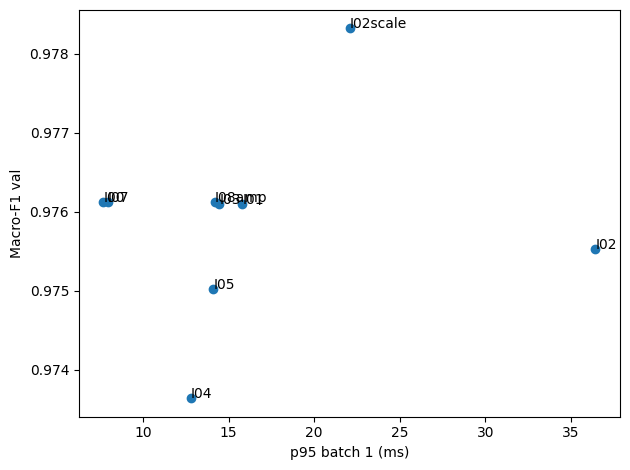

In [15]:
net = load_net(next(r for r in noise_rows if r["exp_id"] == "F01" and r["seed"] == 0))
partner = load_net(PARTNER_SUMMARY)
size = FINAL_CFG.img_size

def logits_from_batch(net, x, spec, partner=None):
    mode, space = spec["mode"], spec.get("space", "prob")
    if mode in ("identity", "fused", "amp", "temperature"):
        return net(x).float()
    if mode == "hflip":
        views = [x, inference.view_hflip(x)]
    elif mode == "crop":
        views = inference.views_multicrop(x, size)
    elif mode == "scale":
        views = inference.views_multiscale(x, spec["sizes"])
    elif mode == "ensemble":
        p = (net(x).float().softmax(1) + partner(x).float().softmax(1)) / 2
        return p.clamp_min(1e-12).log()
    else:
        raise ValueError(mode)
    z = [net(v).float() for v in views]
    if space == "logit":
        return torch.stack(z).mean(0)
    return torch.stack([v.softmax(1) for v in z]).mean(0).clamp_min(1e-12).log()

def predict_method(net, df, spec, partner=None):
    mode = spec["mode"]
    inference_size = size + 32 if mode == "crop" else spec.get("resolution", size)
    loader = loader_for(net, df, inference_size)
    names, labels, logits = [], [], []
    with torch.inference_mode():
        for x, y, filenames in loader:
            x = x.to(DEVICE)
            with torch.autocast(device_type=DEVICE.type, enabled=mode == "amp"):
                z = logits_from_batch(net, x, spec, partner)
            names.extend(filenames); labels.append(y.numpy()); logits.append(z.cpu().numpy())
    return names, np.concatenate(labels), np.concatenate(logits)

def measure_method(net, spec, batch, partner=None):
    mode = spec["mode"]
    resolution = size + 32 if mode == "crop" else spec.get("resolution", size)
    x = torch.randn(batch, 3, resolution, resolution, device=DEVICE)
    def fn():
        with torch.inference_mode(), torch.autocast(device_type=DEVICE.type, enabled=mode == "amp"):
            z = logits_from_batch(net, x, spec, partner)
            return (z / spec.get("T", 1.0)).softmax(1)
    timing = benchmark.bench(fn, warmup=10, iters=100, sync=lambda: torch.cuda.synchronize(DEVICE))
    return {**timing, "batch": batch, "gpu": torch.cuda.get_device_name(DEVICE),
            "dtype": "amp" if mode == "amp" else "fp32", "img_size": resolution,
            "bn_fused": mode == "fused", "torch": str(torch.__version__),
            "preprocessing": "tensor views + aggregation included; PIL/normalize/H2D excluded",
            "images_per_s": batch / (timing["p50"] / 1000)}

specs = [
    {"exp_id": "I00", "mode": "identity", "K": 1},
    {"exp_id": "I01", "mode": "hflip", "K": 2, "space": "prob"},
    {"exp_id": "I02", "mode": "crop", "K": 5, "space": "prob"},
    {"exp_id": "I03", "mode": "hflip", "K": 2, "space": "logit"},
    {"exp_id": "I07", "mode": "temperature", "K": 1},
    {"exp_id": "I08amp", "mode": "amp", "K": 1},
]
if "patch" not in FINAL_CFG.backbone:
    specs += [{"exp_id": "I04", "mode": "identity", "K": 1, "resolution": 288},
              {"exp_id": "I02scale", "mode": "scale", "K": 3, "sizes": [224, 256, 288]}]
same_norm = all(net.pretrained_cfg.get(k) == partner.pretrained_cfg.get(k) for k in ("mean", "std"))
partner_size = PARTNER_SUMMARY["img_size"]
if same_norm and ("patch" not in PARTNER_SUMMARY["backbone"] or partner_size == size):
    specs.append({"exp_id": "I05", "mode": "ensemble", "K": 2})
fused = inference.fuse_conv_bn(net)
sample = torch.randn(2, 3, size, size, device=DEVICE)
with torch.inference_mode():
    fusion_error = (net(sample) - fused(sample)).abs().max().item()
print("Sai số gộp BN:", fusion_error)
if getattr(fused, "lab_bn_fused", False):
    assert fusion_error < 1e-4
    specs.append({"exp_id": "I08bn", "mode": "fused", "K": 1})

inference_rows, inference_cache = [], {}
for spec in specs:
    current = fused if spec["mode"] == "fused" else net
    names, y, z = predict_method(current, val_df, spec, partner)
    T = inference.fit_temperature(z, y) if spec["mode"] == "temperature" else 1.0
    spec["T"] = T
    p = inference.apply_temperature(z, T)
    metrics = compute_metrics(y, p.argmax(1), p)
    inference_cache[spec["exp_id"]] = (names, y, z)
    lat = measure_method(current, spec, 1, partner)
    row = {**spec, "checkpoint": str(run_dir(FINAL_CFG) / "best.pt"),
           "macro_f1_val": metrics["macro_f1"], "top1_val": metrics["top1"], "ece_val": metrics["ece"],
           "p50": lat["p50"], "p95": lat["p95"], "p99": lat["p99"],
           "images_per_s": lat["images_per_s"]}
    inference_rows.append(row)
    for batch in (1, 32):
        latency_rows.append({"exp_id": spec["exp_id"], **(lat if batch == 1 else measure_method(current, spec, batch, partner))})
    save_predictions(OUTPUT_DIR / "predictions" / f'{spec["exp_id"]}_seed0_val.csv', names, y, p)
    save_table(inference_rows, "inference.json"); save_table(latency_rows, "latency.json")
i00 = inference_rows[0]["p50"]
for row in inference_rows:
    row["relative_cost"] = row["p50"] / i00
selected_row = max(inference_rows, key=lambda r: (r["macro_f1_val"], -r["p50"]))
SELECTED_SPEC = {k: copy.deepcopy(v) for k, v in selected_row.items()
                 if k in ("exp_id", "mode", "K", "space", "resolution", "sizes")}
# Khi đã chốt trước test, dùng lại phương pháp đã lưu thay vì chọn lại do nhiễu latency.
saved_plan = OUTPUT_DIR / "final_plan.json"
if saved_plan.exists():
    SELECTED_SPEC = json.loads(saved_plan.read_text())["method"]
print("Chọn từ val:", SELECTED_SPEC)
display(pd.DataFrame(inference_rows))
plt.scatter([r["p95"] for r in inference_rows], [r["macro_f1_val"] for r in inference_rows])
for row in inference_rows:
    plt.annotate(row["exp_id"], (row["p95"], row["macro_f1_val"]))
plt.xlabel("p95 batch 1 (ms)"); plt.ylabel("Macro-F1 val")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "inference_tradeoff.png", dpi=160); plt.show()
save_table(inference_rows, "inference.json")
del net, fused, partner, current
gc.collect(); torch.cuda.empty_cache()


## Bước 4 — Chung kết: ≥ 3 seed, test một lần mỗi seed
1. Chốt cấu hình trên **val**.
2. Chạy cấu hình cuối **và mốc** (`T00` + `I00`) với cùng số seed, bật `save_test_predictions=True`.
3. Dự đoán lưu ở `predictions/<exp_id>_seed<k>_test.csv`. Rồi chạy `eval.py` (ô dưới).

In [16]:
plan = {"config": asdict(FINAL_CFG), "method": SELECTED_SPEC,
        "partner": PARTNER_SUMMARY["checkpoint"], "seeds": [0, 1, 2]}
plan_path = OUTPUT_DIR / "final_plan.json"
if plan_path.exists():
    assert json.loads(plan_path.read_text()) == plan, "Kế hoạch đã chốt khác hiện tại; không đổi sau test"
else:
    plan_path.write_text(json.dumps(plan, indent=2))

final_rows, perclass_rows = [], []
def export_final(summary, spec, calibrate):
    cfg = Config(**summary["config"])
    test_path = OUTPUT_DIR / "predictions" / f"{cfg.exp_id}_seed{cfg.seed}_test.csv"
    val_path = OUTPUT_DIR / "predictions" / f"{cfg.exp_id}_seed{cfg.seed}_val.csv"
    lock = run_dir(cfg) / "test_started.json"
    if not test_path.exists():
        assert not lock.exists(), f"{lock}: test từng bắt đầu nhưng chưa hoàn tất; ghi nhận lỗi, không tự chạy lại"
        current = load_net(summary)
        member = load_net(PARTNER_SUMMARY) if spec["mode"] == "ensemble" else None
        if spec["mode"] == "fused":
            current = inference.fuse_conv_bn(current)
        filenames, labels, z = predict_method(current, val_df, spec, member)
        T = inference.fit_temperature(z, labels) if calibrate else 1.0
        save_predictions(val_path, filenames, labels, inference.apply_temperature(z, T))
        (run_dir(cfg) / "temperature.json").write_text(json.dumps({"T": T, "fit_split": "val"}))
        lock.write_text(json.dumps({"method": spec, "T": T, "seed": cfg.seed}, indent=2))
        # Một lượt qua toàn bộ test; TTA/ensemble nằm bên trong cùng lượt này.
        filenames, labels, z = predict_method(current, test_df, spec, member)
        np.savez(run_dir(cfg) / "final_test_logits.npz", filenames=filenames, y_true=labels, logits=z)
        uncal = inference.apply_temperature(z, 1.0)
        if calibrate:
            save_predictions(OUTPUT_DIR / "predictions" / f"F01uncal_seed{cfg.seed}_test.csv",
                             filenames, labels, uncal)
        save_predictions(test_path, filenames, labels, inference.apply_temperature(z, T))
        del current, member
        gc.collect(); torch.cuda.empty_cache()
    pred = read_pred(str(test_path)); check_against_csv(pred, str(Path(LABELS_DIR) / "test_subset0.csv"))
    val_pred = read_pred(str(val_path)); check_against_csv(val_pred, str(Path(LABELS_DIR) / "val_subset0.csv"), "val")
    metrics = compute_metrics(pred.y_true, pred.y_pred, pred.probs)
    vm = compute_metrics(val_pred.y_true, val_pred.y_pred, val_pred.probs)
    final_rows.append({"exp_id": cfg.exp_id, "seed": cfg.seed, "configuration": json.dumps(asdict(cfg)),
                       "inference": spec["mode"], "macro_f1_val": vm["macro_f1"],
                       **{f"{k}_test": metrics[k] for k in SCALARS}})
    for c, name in enumerate(dataset.CLASS_NAMES):
        perclass_rows.append({"exp_id": cfg.exp_id, "seed": cfg.seed, "class": name,
                              **{k: float(metrics[k][c]) for k in ("support", "precision", "recall", "f1")}})
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(metrics["confusion"], cmap="Blues")
    ax.set_xticks(range(9), dataset.CLASS_NAMES, rotation=90)
    ax.set_yticks(range(9), dataset.CLASS_NAMES)
    ax.set_xlabel("Dự đoán"); ax.set_ylabel("Nhãn thật"); fig.colorbar(im, ax=ax)
    for i in range(9):
        for j in range(9):
            ax.text(j, i, int(metrics["confusion"][i, j]), ha="center", va="center", fontsize=7)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / f"confusion_{cfg.exp_id}_seed{cfg.seed}.png", dpi=160); plt.close(fig)
    wrong = np.flatnonzero(pred.y_true != pred.y_pred)
    hard = [i for i in wrong if {int(pred.y_true[i]), int(pred.y_pred[i])} == {0, 7}]
    chosen = (hard + [i for i in wrong if i not in hard])[:9]
    if chosen:
        fig, axes = plt.subplots(3, 3, figsize=(12, 12))
        for ax in axes.flat:
            ax.axis("off")
        for ax, i in zip(axes.flat, chosen):
            with Image.open(Path(IMAGES_DIR) / pred.filenames[i]) as image:
                ax.imshow(image.convert("RGB"))
            ax.set_title(f"{dataset.CLASS_NAMES[pred.y_true[i]]}\n→ {dataset.CLASS_NAMES[pred.y_pred[i]]}", fontsize=8)
        fig.tight_layout(); fig.savefig(OUTPUT_DIR / f"errors_{cfg.exp_id}_seed{cfg.seed}.png", dpi=160); plt.close(fig)

for seed in (0, 1, 2):
    baseline = run(replace(BASE, seed=seed, save_test_predictions=False))
    finalist = run(replace(FINAL_CFG, seed=seed, save_test_predictions=False))
    export_final(baseline, {"mode": "identity", "K": 1, "resolution": baseline["img_size"]}, False)
    export_final(finalist, SELECTED_SPEC, True)
    save_table(final_rows, "final.json"); save_table(perclass_rows, "perclass.json")
display(pd.DataFrame(final_rows))


Dùng kết quả đã lưu: /kaggle/working/lab_day2_output/runs/T00/seed0
Dùng kết quả đã lưu: /kaggle/working/lab_day2_output/runs/F01/seed0
Dùng kết quả đã lưu: /kaggle/working/lab_day2_output/runs/T00/seed1
Dùng kết quả đã lưu: /kaggle/working/lab_day2_output/runs/F01/seed1
Dùng kết quả đã lưu: /kaggle/working/lab_day2_output/runs/T00/seed2
Dùng kết quả đã lưu: /kaggle/working/lab_day2_output/runs/F01/seed2


,exp_id,seed,configuration,inference,macro_f1_val,top1_test,macro_f1_test,balanced_acc_test,ece_test,nll_test
0,T00,0,"{""exp_id"": ""T00"", ""seed"": 0, ""fold"": 0, ""backb...",identity,0.971149,0.978614,0.973251,0.978881,0.010186,0.083333
1,F01,0,"{""exp_id"": ""F01"", ""seed"": 0, ""fold"": 0, ""backb...",scale,0.978319,0.982321,0.978153,0.979159,0.006474,0.048327
2,T00,1,"{""exp_id"": ""T00"", ""seed"": 1, ""fold"": 0, ""backb...",identity,0.973627,0.979184,0.972806,0.971854,0.008626,0.075721
3,F01,1,"{""exp_id"": ""F01"", ""seed"": 1, ""fold"": 0, ""backb...",scale,0.974141,0.983177,0.978205,0.975462,0.005441,0.053934
4,T00,2,"{""exp_id"": ""T00"", ""seed"": 2, ""fold"": 0, ""backb...",identity,0.972658,0.979184,0.973920,0.977051,0.007968,0.066188
5,F01,2,"{""exp_id"": ""F01"", ""seed"": 2, ""fold"": 0, ""backb...",scale,0.976821,0.983747,0.979243,0.977831,0.006858,0.050439


In [17]:
# Tính chỉ số theo đúng định nghĩa của lớp (đã viết sẵn, không sửa eval.py):
!python {REPO_DIR}/eval.py score --pred "predictions/F01_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag F01 --out eval_out
!python {REPO_DIR}/eval.py score --pred "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --tag T00 --out eval_out

### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9831 ± 0.0007 |
| macro-F1 | 0.9785 ± 0.0006 |
| balanced accuracy | 0.9775 ± 0.0019 |
| ECE (15 bin) | 0.0063 ± 0.0007 |
| NLL | 0.0509 ± 0.0028 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.972 ± 0.003 | 0.963 ± 0.007 | 0.967 ± 0.005 | 226 |
| Lantana | 0.987 ± 0.010 | 0.978 ± 0.010 | 0.983 ± 0.003 | 213 |
| Parkinsonia | 0.975 ± 0.006 | 0.992 ± 0.007 | 0.983 ± 0.006 | 207 |
| Parthenium | 0.998 ± 0.003 | 0.977 ± 0.007 | 0.988 ± 0.004 | 205 |
| Prickly acacia | 0.966 ± 0.005 | 0.967 ± 0.000 | 0.966 ± 0.003 | 213 |
| Rubber vine | 0.982 ± 0.010 | 0.982 ± 0.006 | 0.982 ± 0.004 | 202 |
| Siam weed | 0.985 ± 0.003 | 0.991 ± 0.000 | 0.988 ± 0.001 | 215 |
| Snake weed | 0.966 ± 0.008 | 0.958 ± 0.012 | 0.961 ± 0.003 | 204 |
| Negative | 0.987 ± 0.001 | 0.990 ± 0.003 | 0.988 ± 0.001 | 1822 |

Đã lưu kết quả vào eval_out/F01_*
### T00 (3 seed: [0, 1, 2]; 3507 

In [18]:
# Tự chấm phần I của RUBRIC (đề xuất, giảng viên xác nhận). Thêm --uncal, --final-val, --latency-p95-ms nếu có.
!python {REPO_DIR}/eval.py grade --final "predictions/F01_seed*_test.csv" \
    --baseline "predictions/T00_seed*_test.csv" \
    --test-csv {LABELS_DIR}/test_subset0.csv --labels {LABELS_DIR}/labels.csv --out eval_out

## Tự chấm RUBRIC mục I (đề xuất; giảng viên xác nhận)

| Mã | Tiêu chí | Điểm | Tối đa | Chi tiết |
|---|---|---|---|---|
| I1 | Top-1 accuracy test | 7 | 7 | 98.31% (mean 3 seed) |
| I2 | Macro-F1 cải thiện so với mốc | 4 | 5 | final 0.9785, mốc 0.9733, Δ=+0.0052, s=0.0006 |
| I3 | Recall hai lớp khó | 4 | 4 | Chinee Apple 96.3% (mốc 88.5%), Snake Weed 95.8% (mốc 88.8%) |
| I4a | ECE sau TS < ECE trước | - | 1 | chưa chấm được (thiếu --uncal) |
| I4b | Chênh macro-F1 val/test <= 0.02 | - | 1 | chưa chấm được (thiếu --final-val) |
| I5 | Cấu hình thời gian thực | - | 2 | chưa chấm được (thiếu --latency-p95-ms) |

**Tổng các ý đã chấm: 15 / 16** (phần I tối đa 20).
Chưa chấm được: I4a, I4b, I5.

Ngưỡng điểm là TẠM THỜI (xem khối hằng số đầu file eval.py và RUBRIC.md mục I).


## Bước 5 — Sản phẩm
`results.xlsx` (các sheet ở GUIDE.md mục 6.1), `curves/<exp_id>_*.png`, `report.md`, `predictions/`, `code/`.

In [19]:
backbones = pd.DataFrame(backbone_rows).drop(columns=["config"])
training = pd.DataFrame(training_rows).drop(columns=["config"])
infer = pd.DataFrame(inference_rows)
final = pd.DataFrame(final_rows)
pc = pd.DataFrame(perclass_rows)
latency = pd.DataFrame(latency_rows)
aggregate = final.groupby("exp_id").agg({c: ["mean", "std"] for c in
    ["macro_f1_val", "macro_f1_test", "top1_test", "ece_test"]})
aggregate.columns = ["_".join(c) for c in aggregate.columns]
aggregate["seed"] = "mean/std (ddof=1, n=3)"
aggregate = aggregate.reset_index()
final = pd.concat([final, aggregate], ignore_index=True)
pc_aggregate = pc.groupby(["exp_id", "class"]).agg({k: ["mean", "std"] for k in
    ["support", "precision", "recall", "f1"]})
pc_aggregate.columns = ["_".join(c) for c in pc_aggregate.columns]
pc = pd.concat([pc, pc_aggregate.reset_index().assign(seed="mean/std")], ignore_index=True)
summary = pd.concat([backbones.assign(stage="backbone"), training.assign(stage="training"),
                     infer.assign(stage="inference")], ignore_index=True).sort_values("macro_f1_val", ascending=False).head(10)
sheets = {"Backbones": backbones, "Training": training, "Inference": infer, "Final": final,
          "PerClass": pc, "Latency": latency, "Summary": summary}
from openpyxl.styles import PatternFill
with pd.ExcelWriter(OUTPUT_DIR / "results.xlsx", engine="openpyxl") as writer:
    for name, frame in sheets.items():
        frame = frame.map(lambda v: json.dumps(v) if isinstance(v, (dict, list)) else v)
        frame.to_excel(writer, sheet_name=name, index=False)
        ws = writer.sheets[name]; ws.freeze_panes = "A2"; ws.auto_filter.ref = ws.dimensions
        for cell in ws[1]:
            cell.fill = PatternFill("solid", fgColor="D9EAF7")
        for column in ws.columns:
            ws.column_dimensions[column[0].column_letter].width = min(45, max(14, len(str(column[0].value)) + 2))
            for cell in column[1:]:
                if isinstance(cell.value, float):
                    cell.number_format = "0.0000"
        if "macro_f1_val" in frame.columns and not frame.empty:
            best_pos = int(np.argmax(frame["macro_f1_val"].fillna(-1).to_numpy())) + 2
            for cell in ws[best_pos]:
                cell.fill = PatternFill("solid", fgColor="E2F0D9")
for row in final_rows:
    path = OUTPUT_DIR / "predictions" / f'{row["exp_id"]}_seed{row["seed"]}_test.csv'
    pred = read_pred(str(path))
    check_against_csv(pred, str(Path(LABELS_DIR) / "test_subset0.csv"))
    m = compute_metrics(pred.y_true, pred.y_pred, pred.probs)
    assert all(abs(row[f"{k}_test"] - m[k]) < 1e-10 for k in SCALARS)
for row in backbone_rows + training_rows + noise_rows:
    assert list((OUTPUT_DIR / "curves").glob(f'{row["exp_id"]}_*_seed{row["seed"]}.png')), row["exp_id"]
print("Đã xuất:", OUTPUT_DIR / "results.xlsx")
print("Viết report.md theo GUIDE 6.3 dựa trên bảng/log thật và ảnh EDA, confusion, errors.")


Đã xuất: /kaggle/working/lab_day2_output/results.xlsx
Viết report.md theo GUIDE 6.3 dựa trên bảng/log thật và ảnh EDA, confusion, errors.
